In [1]:
pip install pydicom

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 2.0 MB 7.3 MB/s 


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pydicom
import numpy
import numpy as np
import cv2
import os
import math
import pylab
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from scipy import ndimage
from skimage import morphology

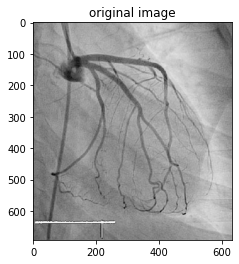

In [4]:
#load image
image_path='/content/drive/MyDrive/medical imaging/medical imaging/Type3.jpg'
original_img=cv2.imread(image_path)
plt.title('original image')
plt.imshow(original_img)
plt.savefig('/content/drive/MyDrive/medical imaging/medical imaging/readme-assets/types3/one.jpg',bbox_inches='tight',transparent=True)

Old Dimensions(633,692)
New dimensions(507,554)


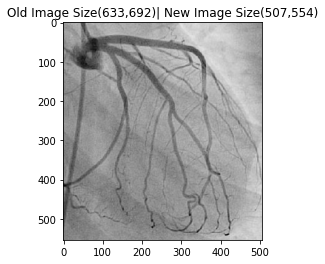

In [5]:
#crop the borders by 10%
print(f'Old Dimensions({original_img.shape[1]},{original_img.shape[0]})')
x_new=int(original_img.shape[1]*.1)
y_new=int(original_img.shape[0]*.1)
img_cropped=original_img[y_new:original_img.shape[0]-y_new,x_new:original_img.shape[1]-x_new]
print(f'New dimensions({img_cropped.shape[1]},{img_cropped.shape[0]})')
plt.title(f'Old Image Size({original_img.shape[1]},{original_img.shape[0]})| New Image Size({img_cropped.shape[1]},{img_cropped.shape[0]})')
plt.imshow(img_cropped)
plt.savefig("/content/drive/MyDrive/medical imaging/medical imaging/readme-assets/types3/three.jpg",bbox_inches="tight", transparent = True)
plt.show()



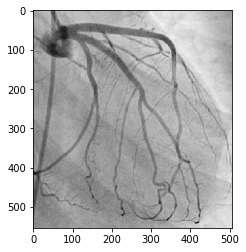

In [6]:
#Step 3 convert image to gray
gray = cv2.cvtColor(img_cropped, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap = 'gray')
plt.savefig('/content/drive/MyDrive/medical imaging/medical imaging/readme-assets/types3/three.jpg', bbox_inches='tight', transparent = True)
plt.show()

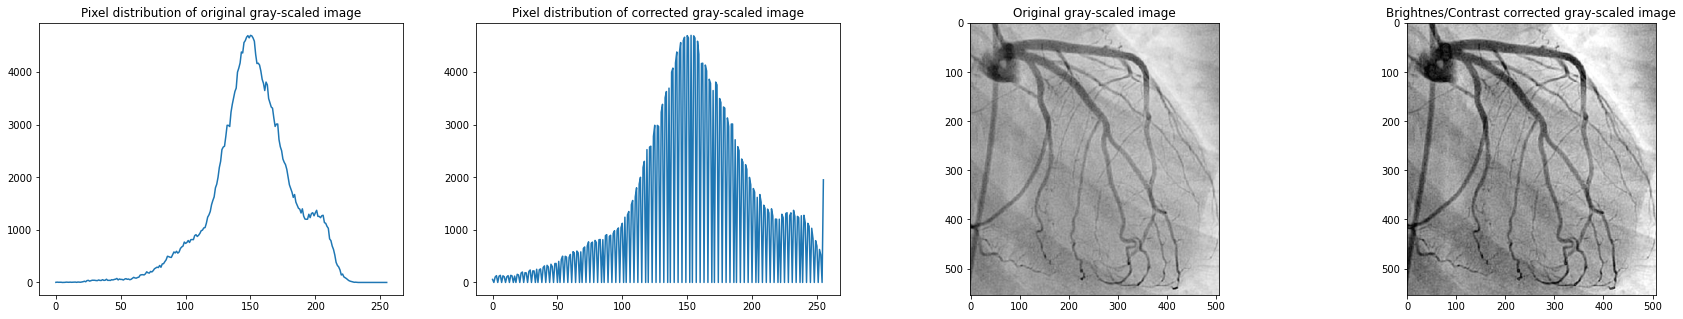

In [7]:
#Step 4 - Apply brightness correction to gray scaled image

def automatic_brightness_and_contrast(image: np.array, clip_hist_percent: int = 1) -> np.array:
    
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    hist_size = len(hist)

    accumulator = []
    accumulator.append(float(hist[0]))
    for index in range(1, hist_size):
        accumulator.append(accumulator[index - 1] + float(hist[index]))

    # Locate points to clip
    maximum = accumulator[-1]
    clip_hist_percent *= (maximum / 100.0)
    clip_hist_percent /= 2.0

    # Locate left cut
    minimum_gray = 0
    while accumulator[minimum_gray] < clip_hist_percent:
        minimum_gray += 1

    # Locate right cut
    maximum_gray = hist_size - 1
    while accumulator[maximum_gray] >= (maximum - clip_hist_percent):
        maximum_gray -= 1

    # Calculate alpha and beta values
    alpha = 255 / (maximum_gray - minimum_gray)
    beta = -minimum_gray * alpha

    auto_result = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)
    return auto_result

original_hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
gray_corrected = automatic_brightness_and_contrast(gray)
new_hist = cv2.calcHist([gray_corrected], [0], None, [256], [0, 256])
fig, ax = plt.subplots(1, 4, figsize = (30,5))
ax[0].plot(original_hist)
ax[0].set_title('Pixel distribution of original gray-scaled image')
ax[1].plot(new_hist)
ax[1].set_title('Pixel distribution of corrected gray-scaled image')
ax[2].imshow(gray, cmap = 'gray')
ax[2].set_title('Original gray-scaled image')
ax[3].imshow(gray_corrected, cmap = 'gray')
ax[3].set_title('Brightnes/Contrast corrected gray-scaled image')
plt.savefig('/content/drive/MyDrive/medical imaging/medical imaging/readme-assets/types3/four.jpg', bbox_inches='tight', transparent = True)
plt.show()

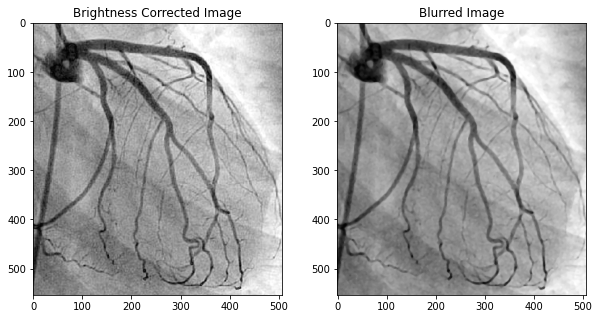

In [8]:
#Step 5 Blur the image to reduce noise
fig, ax = plt.subplots(1,2, figsize = (10,5))
blurred = cv2.medianBlur(gray_corrected, 5)
ax[0].imshow(gray_corrected, cmap = 'gray')
ax[0].set_title('Brightness Corrected Image')
ax[1].imshow(blurred, cmap = 'gray')
ax[1].set_title('Blurred Image')
plt.savefig('/content/drive/MyDrive/medical imaging/medical imaging/readme-assets/types3/five.jpg', bbox_inches='tight', transparent = True)
plt.show()

Image Dimensions
Height 554 Width 507
# Rows: 12 | # Columns: 11
Total Blocks: 132
Total Pixel Area of each block 2209 | (47x47)


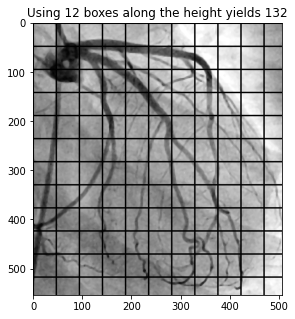

In [9]:
#Step 6 Create blocksize
blurred_copy = blurred.copy() 
print(f'Image Dimensions\nHeight {blurred_copy.shape[0]} Width {blurred_copy.shape[1]}')
height_boxes = 12
block_size = int(blurred.shape[0] / height_boxes) 
block_size = block_size + 1 if block_size % 2 == 0 else block_size 

neighbors = block_size * block_size 

width_boxes = int(blurred.shape[1] / block_size) 
width_boxes = width_boxes + 1 if width_boxes % 2 == 0 else width_boxes 

total_blocks = (height_boxes * width_boxes)

print(f'# Rows: {height_boxes} | # Columns: {width_boxes}')
print(f'Total Blocks: {total_blocks}')
print(f'Total Pixel Area of each block {neighbors} | ({block_size}x{block_size})')
for y in range(0, blurred.shape[0], block_size):
    for x in range(0, blurred.shape[1], block_size):
        cv2.rectangle(blurred_copy, (x, y), (x+block_size, y+block_size), (0,0,255), 2)
    
plt.figure(figsize=(20,5))
plt.title(f'Using {height_boxes} boxes along the height yields {total_blocks}')
plt.imshow(blurred_copy, cmap = 'gray')
plt.savefig('/content/drive/MyDrive/medical imaging/medical imaging/readme-assets/types3/six.jpg', bbox_inches='tight', transparent = True)
plt.show()

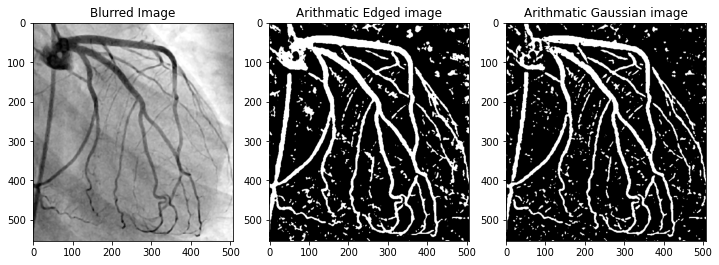

In [10]:
#Step 7 Apply adaptive thresholding using the block size above
constant = 10
edged_gaussian = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, block_size, constant)
edged_arithmatic = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, block_size, constant)
fig, ax = plt.subplots(1, 3, figsize = (10, 5))
ax[0].imshow(blurred, cmap = 'gray')
ax[0].set_title('Blurred Image')
ax[1].imshow(edged_arithmatic, cmap = 'gray')
ax[1].set_title('Arithmatic Edged image')
ax[2].imshow(edged_gaussian, cmap = 'gray')
ax[2].set_title('Arithmatic Gaussian image')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/medical imaging/medical imaging/readme-assets/types3/seven.jpg', bbox_inches='tight', transparent = True)
plt.show()
edged_adap = edged_arithmatic.copy()

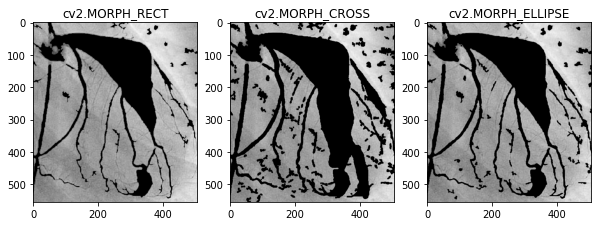

In [11]:
#Step 8, get contours
image_dict = {}
struct_element = {'cv2.MORPH_RECT': cv2.MORPH_RECT, 'cv2.MORPH_CROSS': cv2.MORPH_CROSS, 'cv2.MORPH_ELLIPSE': cv2.MORPH_ELLIPSE}
fig, ax = plt.subplots(1, 3, figsize = (10,5))
img_idx = 0
output_dict = {}
for k, e in struct_element.items():
    min_contour_area = 50 
    thresh = cv2.morphologyEx(edged_adap, e, np.ones((3,3), np.uint8))
    contours = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]
    contours = [i for i in contours if cv2.contourArea(i) >= min_contour_area]
    edged_contour = img_cropped.copy()
    for idx, c1 in enumerate(contours): 
        cv2.drawContours(edged_contour, [c1], -1, (0,0,0), -1)
    edged_contour = cv2.cvtColor(edged_contour, cv2.COLOR_BGR2GRAY)
    ax[img_idx].imshow(edged_contour, cmap = 'gray')
    ax[img_idx].set_title(f'{k}')
    img_idx += 1
    output_dict[k] = edged_contour
    
fig.savefig('/content/drive/MyDrive/medical imaging/medical imaging/readme-assets/types3/eight.jpg', bbox_inches='tight', transparent = True)
plt.show()

edged_contour = output_dict['cv2.MORPH_ELLIPSE'].copy()

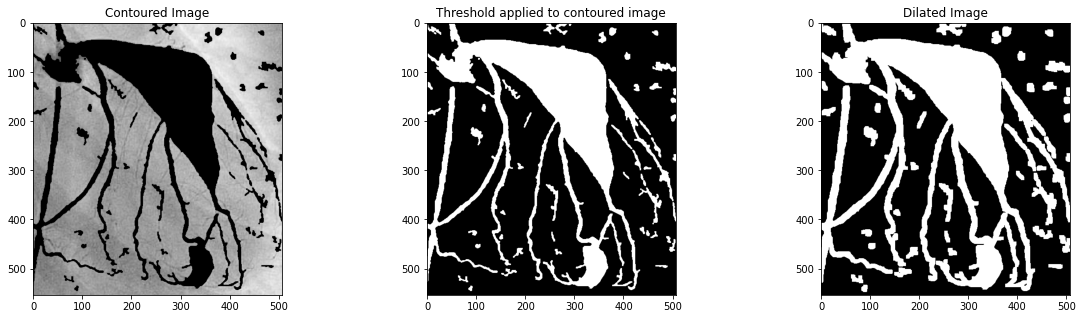

In [12]:
#Step 9 Perform another round of threshold to include only the contoured areas then dilate the image to reduce the space between contours
threshed = cv2.threshold(edged_contour, 0, 255, cv2.THRESH_BINARY_INV)[1]
dilated = cv2.dilate(threshed, None, iterations = 2)
fig, ax = plt.subplots(1,3, figsize=(20,5))
ax[0].imshow(edged_contour, cmap = 'gray')
ax[0].set_title('Contoured Image')
ax[1].imshow(threshed, cmap = 'gray')
ax[1].set_title('Threshold applied to contoured image')
ax[2].imshow(dilated, cmap = 'gray')
ax[2].set_title('Dilated Image')
plt.savefig('/content/drive/MyDrive/medical imaging/medical imaging/readme-assets/types3/nine.jpg', bbox_inches='tight', transparent = True)
plt.show()

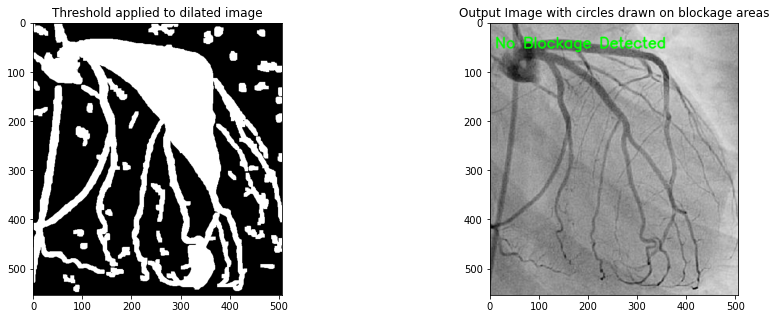

In [13]:
#Step 10 Another contour operation to get outlines of the dilated image.  
def find_if_close(cnt1: list, cnt2: list, min_dist: int=10):
    
    row1, row2 = cnt1.shape[0], cnt2.shape[0]
    for i in range(row1):
        for j in range(row2):
            dist = np.linalg.norm(cnt1[i] - cnt2[j])
            #             print(dist)
            if abs(dist) < min_dist:
                return i
            elif i == row1 - 1 and j == row2 - 1:
                return False

min_contour_area = 1250
output_image = img_cropped.copy()
thresh = cv2.morphologyEx(dilated, cv2.MORPH_ELLIPSE, np.ones((3,3), np.uint8))
contours = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]
contours = [i for i in contours if cv2.contourArea(i) > min_contour_area]
detections = 0
for idx1, c1 in enumerate(contours):
    for idx2, c2 in enumerate(contours):
        if idx2 == idx1:
            continue
        point = find_if_close(c1, c2, min_dist = 10)
        if point: 
            detections += 1
            center = tuple(contours[idx1][point].squeeze())
            cv2.circle(output_image, center, 25, (0,0,255), 2)

message = f'Possible Blockage' if detections > 0 else 'No Blockage Detected'
color = (0, 0, 255) if detections > 0 else (0, 255, 0)
output_image = cv2.putText(output_image, message, (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2, cv2.LINE_AA)

fig, ax = plt.subplots(1, 2, figsize = (15, 5))
ax[0].imshow(thresh, cmap = 'gray')
ax[0].set_title('Threshold applied to dilated image')
ax[1].imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
ax[1].set_title('Output Image with circles drawn on blockage areas')
plt.savefig('/content/drive/MyDrive/medical imaging/medical imaging/readme-assets/types3/ten.jpg', bbox_inches='tight', transparent = True)
plt.show()